In [76]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Entregável Machine Learning
Luiz Paulo Corrêa da Silva

# Regressão — Student Performance
Dado um dataset de informações demográficas, familiares e hábitos de estudo de alunos do curso de matemática, queremos prever sua pontuação média (score) das 3 avaliações.

## Análise Exploratória
Abaixo, iremos realizar a EDA inicial, identificando os dados numéricos x categóricos.

In [77]:
# abrindo o dataset no pandas
df_original = pd.read_csv("regressao/train.csv")
df_original.info()
df_original.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    str    
 1   sex         395 non-null    str    
 2   age         395 non-null    int64  
 3   address     395 non-null    str    
 4   famsize     395 non-null    str    
 5   Pstatus     395 non-null    str    
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    str    
 9   Fjob        395 non-null    str    
 10  reason      395 non-null    str    
 11  guardian    395 non-null    str    
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    str    
 16  famsup      395 non-null    str    
 17  paid        395 non-null    str    
 18  activities  395 non-null    str    
 19  nursery     395 non-null    str    
 20 

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.00,16.00,17.00,18.00,22.00
Medu,395.0,2.749367,1.094735,0.00,2.00,3.00,4.00,4.00
Fedu,395.0,2.521519,1.088201,0.00,2.00,2.00,3.00,4.00
traveltime,395.0,1.448101,0.697505,1.00,1.00,1.00,2.00,4.00
studytime,395.0,2.035443,0.839240,1.00,1.00,2.00,2.00,4.00
failures,395.0,0.334177,0.743651,0.00,0.00,0.00,0.00,3.00
famrel,395.0,3.944304,0.896659,1.00,4.00,4.00,5.00,5.00
freetime,395.0,3.235443,0.998862,1.00,3.00,3.00,4.00,5.00
goout,395.0,3.108861,1.113278,1.00,2.00,3.00,4.00,5.00
Dalc,395.0,1.481013,0.890741,1.00,1.00,1.00,2.00,5.00


Com a saída acima, em conjunto com a [documentacao](regressao/student.txt) fornecida, identificamos:
1. Não há entradas nulas
2. Muitas colunas são categóricas. Assim, para utilizarmos regressão com coeficientes lineares, por exemplo, teríamos que utilizar técnicas como OHC (One Hot Encoding).

Entretanto, espera-se que o OHC com regressão aumente muito a dimensionalidade dos dados e cause overfit (memorização). Assim, é interessante combinar a regressão linear com modelos de regressão regularizados, como o Lasso.

Além disso, modelos como o Random Forest Regressor lidam bem com colunas categóricas, não sendo necessário aplicar técnicas como o OHC. Logo, vale a pena testar também a precisão de um modelo dessa natureza no dataset fornecido.


## Limpeza/Pré Processamento

Para realizar o treinamento dos modelos de regressão e random forest regressor, criarei dois dataframes diferentes. Um deles aplicará OHC nas colunas categóricas para o de treinamento dos modelos de regressão linear. Nesse sentido, com o objetivo de mitigar a possibilidade de overfit, não irei aplicar o OHC para as variáveis ordinais (como health e famrel), pois, nesses casos, aumentar um ponto na escala gera um impacto progressivo na nota.

O segundo dataframe não terá OHC nos dados e será utilizado para treinar o modelo Random Forest Regressor. 

Segue abaixo o código que realiza o pré processamento.



In [78]:
df = df_original.copy()

# primeiro mapeamos as colunas do tipo string para numérico via label encoder
colunas_texto = ['school', 'sex', 'address', 'famsize', 'Pstatus', 
                 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 
                 'famsup', 'paid', 'activities', 'nursery', 'higher', 
                 'internet', 'romantic']

dicionario_encoders = {}

#alteramos o df
for col in colunas_texto:
    #cria um tradutor para esta coluna
    le = LabelEncoder()
    
    #substitui o texto por números
    df[col] = le.fit_transform(df[col])
    
    # salva o tradutor
    dicionario_encoders[col] = le

display(df)

df_ohc = df.copy()

# definindo as colunas que não tem ordem
colunas_para_ohc = [
    'school', 'sex', 'address', 'famsize', 'Pstatus', 
    'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 
    'famsup', 'paid', 'activities', 'nursery', 'higher', 
    'internet', 'romantic'
]

df_ohc = pd.get_dummies(df_ohc, columns=colunas_para_ohc, drop_first=True, dtype=int)
df_ohc.info()




,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,0,0,18,1,0,0,4,4,0,4,...,0,0,4,3,4,1,1,3,6,5.67
1,0,0,17,1,0,1,1,1,0,2,...,1,0,5,3,3,1,1,3,4,5.33
2,0,0,15,1,1,1,1,1,0,2,...,1,0,4,3,2,2,3,3,10,8.33
3,0,0,15,1,0,1,4,2,1,3,...,1,1,3,2,2,1,1,5,2,14.67
4,0,0,16,1,0,1,3,3,2,2,...,0,0,4,3,2,1,2,5,4,8.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,1,1,20,1,1,0,2,2,3,3,...,0,0,5,5,4,4,5,4,11,9.00
391,1,1,17,1,1,1,3,1,3,3,...,1,0,2,4,5,3,4,2,3,15.33
392,1,1,21,0,0,1,1,1,2,2,...,0,0,5,5,3,3,3,3,3,8.33
393,1,1,18,0,1,1,3,2,3,2,...,1,0,4,4,1,3,4,5,0,11.00


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 40 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           395 non-null    int64  
 1   Medu          395 non-null    int64  
 2   Fedu          395 non-null    int64  
 3   traveltime    395 non-null    int64  
 4   studytime     395 non-null    int64  
 5   failures      395 non-null    int64  
 6   famrel        395 non-null    int64  
 7   freetime      395 non-null    int64  
 8   goout         395 non-null    int64  
 9   Dalc          395 non-null    int64  
 10  Walc          395 non-null    int64  
 11  health        395 non-null    int64  
 12  absences      395 non-null    int64  
 13  score         395 non-null    float64
 14  school_1      395 non-null    int64  
 15  sex_1         395 non-null    int64  
 16  address_1     395 non-null    int64  
 17  famsize_1     395 non-null    int64  
 18  Pstatus_1     395 non-null    int64  
 19


## Inferência
Com os dois dataframes gerados acima, podemos seguir para o treinamento e inferência dos modelos. Utilizaremos a biblioteca `scikit-learn` para isso.

Abaixo, segue o código que treina os modelos de **regressão linear**, **regressão linear regularizada** e **random forest regressor**.



In [79]:
y = df['score']

#x para os modelos de regressao (com ohc)
x_ohc = df_ohc.drop(columns=['score'])

#x para o random forest (sem ohc)
x = df.drop(columns='score')

# dividindo em 80% para treino e 20% para validação
X_train_ohc, X_val_ohc, y_train, y_val = train_test_split(x_ohc, y, test_size=0.2, random_state=42)
X_train, X_val, _, _= train_test_split(x, y, test_size=0.2, random_state=42)

#instanciando os modelos
modelo_lr = LinearRegression()
modelo_lasso = Lasso(alpha=0.1, random_state=42)
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)

modelo_lr.fit(X_train_ohc, y_train)
modelo_lasso.fit(X_train_ohc, y_train)
modelo_rf.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_val_ohc)
pred_lasso = modelo_lasso.predict(X_val_ohc)
pred_rf = modelo_rf.predict(X_val)

#realizando treinamento extra com 100% dos dados para envio no kaggle
modelo_rf_oficial = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_oficial.fit(x, y)



,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Métrica de Avaliação
Abaixo, exibimos as métricas obtidas pelos modelos. Note que o Random Forest foi a melhor entre elas. Selecionarei ele para o envio das previsões no kaggle. Assim, adicionei um treinamento extra no final do código acima, que considera 100% do dataset para maior acurácia.

Um ponto curioso é que a regressão regularizada apresentou uma performance inferior comparada com a regressão simples. É interessante se aprofundar melhor nessa questão e, talvez, estudar mais a fundo sobre a configuração dos parâmetros de treinamento desse tipo de modelo (como o `alpha`, por exemplo).


In [80]:
print("=== PLACAR DO RMSE ===")
print(f"1. Regressão Linear Simples: {rmse_lr:.4f} pontos de erro médio")
print(f"2. Regressão Regularizada (Lasso): {rmse_lasso:.4f} pontos de erro médio")
print(f"3. Random Forest Regressor: {rmse_rf:.4f} pontos de erro médio")

=== PLACAR DO RMSE ===
1. Regressão Linear Simples: 3.3750 pontos de erro médio
2. Regressão Regularizada (Lasso): 3.4450 pontos de erro médio
3. Random Forest Regressor: 3.2672 pontos de erro médio


## Parte 2:  Classificação — Breast Cancer
Nesse dataset, recebemos informações sobre células de uma massa mamária. Precisamos classificar as células como um tumor maligno ou benigno.

Abaixo, iremos realizar a EDA inicial dos dados
### Análise Exploratória


In [81]:
df_original = pd.read_csv("classiicacao/train2.csv")
df_original.info()
df_original.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


Note que, no dataset, há apenas uma coluna do tipo string. Converteremos ela para binário para o treinamento do modelo. 

Para esse problema, utilizarei dois modelos diferentes e verificarei qual se sai melhor. O primeiro será uma **regressão logística** com padronização de dados (importante para esse tipo de modelo) e o segundo será **random forest**. 

Abaixo, criarei dois dataframes (um para cada modelo) e transformarei a coluna dependente em binária.
### Pré-Processamento


In [82]:
df = df_original.copy()

# convertendo a coluna alvo para binario
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# dividindo em Treino (80%) e Validação (20%). o stratify=y serve para que a proporção 63%/37% seja mantida no treino e na validação
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# dataframe do random forest (sem padronização)
X_train_rf = X_train.copy()
X_val_rf = X_val.copy()

#dataframe da regressao logistica (com padronização)
scaler = StandardScaler()
X_train_log = scaler.fit_transform(X_train)
X_val_log = scaler.transform(X_val)



### Modelo de Inferência


Abaixo, realizarei o treinamento de ambos os modelos. No fim, plotarei a matriz de confusão de ambos para analisar os falsos positivos e negativos de ambos os modelos. Por se tratar de previsões de doenças perigosas, priorizarei o modelo que apresentar o menor número de falsos negativos. 

Acurácia da Regressão Logística: 96.49%
Acurácia do Random Forest: 97.37%



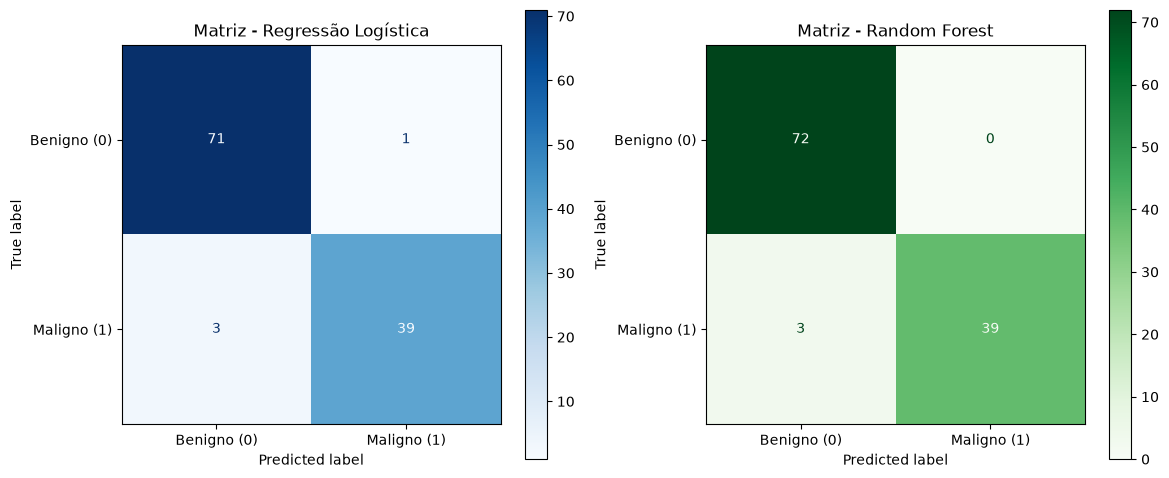

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [83]:
# treinando regressao logistica
modelo_log = LogisticRegression(random_state=42)
modelo_log.fit(X_train_log, y_train)

# treinando random forest
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_rf, y_train)

# realizando inferencia e avaliacao
pred_log = modelo_log.predict(X_val_log)
pred_rf = modelo_rf.predict(X_val_rf)

acc_log = accuracy_score(y_val, pred_log)
acc_rf = accuracy_score(y_val, pred_rf)

print(f"Acurácia da Regressão Logística: {acc_log * 100:.2f}%")
print(f"Acurácia do Random Forest: {acc_rf * 100:.2f}%\n")

# gerando matrizes de confusao

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# regressao logistica
cm_log = confusion_matrix(y_val, pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Benigno (0)', 'Maligno (1)'])
disp_log.plot(cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz - Regressão Logística')

# random Forest
cm_rf = confusion_matrix(y_val, pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Benigno (0)', 'Maligno (1)'])
disp_rf.plot(cmap='Greens', ax=ax[1])
ax[1].set_title('Matriz - Random Forest')

plt.tight_layout()
plt.show()

#realizando treinamento extra com 100% dos dados para envio no kaggle
modelo_rf_oficial_class = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf_oficial_class.fit(X, y)


### Avaliação

Acima, podemos perceber que o modelo random forest foi mais preciso do que a regressão logística com padronização.

A matriz de confusão nos mostra o comportamento da previsão em 20% dos dados de treinamento (114 pacientes de 569). 

Na diagonal principal, nós vemos o número de acertos. Nesse caso, o modelo de Regressão Logística acertou a previsão em 110 pacientes de 114, enquanto que o Random Forest acertou em 111 de 114.

Ambos os modelos produziram 3 falsos negativos, identificados no quadrante inferior esquerdo. Isso significa que 3 tumores foram classificados como benignos de forma errada. Para esse tipo de problema, o ideal é sempre tentar minimizar esse número. Para uma continuação desse trabalho, seria interessante procurar maneiras de diminuir os falsos negativos e, caso possível, ceder parte da precisão dos falsos positivos para os falsos negativos.

Além disso, o modelo de Regressão Logística gerou 1 falso positivo, enquanto que o Random Forest não gerou nenhum. Isso pode ser identificado no quadrante superior direito e significa que o modelo classificou um tumor como maligno, quando na verdade ele era benigno.

Portanto, considerando que ambos os modelos apresentaram o mesmo número de falsos negativos, escolherei o Random Forest para a previsão dos dados de teste por apresentar acurácia maior (97.36% X 96.49)

Abaixo, gerar as previsões para envio no Kaggle, considerando os modelos escolhidos no problema 1 e 2.

## Parte 3: Submissão no Kaggle

In [85]:
 #gerando a submissao do problema 1 (regressao)
df_teste_reg = pd.read_csv('regressao/test.csv')

# primeiro mapeamos as colunas do tipo string para numérico via label encoder
colunas_texto = ['school', 'sex', 'address', 'famsize', 'Pstatus', 
                 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 
                 'famsup', 'paid', 'activities', 'nursery', 'higher', 
                 'internet', 'romantic']

#alteramos o df
for col in colunas_texto:
    df_teste_reg[col] = dicionario_encoders[col].transform(df_teste_reg[col])

previsoes_reg = modelo_rf_oficial.predict(df_teste_reg)
sub_reg = pd.DataFrame({
    'id': df_teste_reg.index,
    'score': previsoes_reg
})

#salva o csv
sub_reg.to_csv('regressao/previsao.csv', index=False)
# gerando a submissao 2 do problema (classificacao)
df_teste_class = pd.read_csv('classiicacao/test2.csv')
previsoes_class = modelo_rf_oficial_class.predict(df_teste_class)
sub_class = pd.DataFrame({
    'id': df_teste_class.index, 
    'diagnosis': previsoes_class
})
# salva o csv
sub_class.to_csv('classiicacao/previsao2.csv', index=False) 